In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
data_folder = '/content/drive/MyDrive/ProyectoTesis/Datasets'

In [ ]:
import pandas as pd
import glob
import os
all_csv_files = sorted(glob.glob(os.path.join(data_folder, '*.csv')))
print("Archivos encontrados:", [os.path.basename(f) for f in all_csv_files])

# Leer y concatenar todos los archivos
df_list = []
for file in all_csv_files:
    print(f"Leyendo: {os.path.basename(file)}")
    df = pd.read_csv(file, low_memory=False)
    df_list.append(df)

# Unir todo en un solo DataFrame
full_df = pd.concat(df_list, axis=0, ignore_index=True)
print("Shape dataset combinado:", full_df.shape)

# Normaliza nombres de columnas: sin espacios, minúsculas y _ en vez de espacios
full_df.columns = full_df.columns.str.strip().str.lower().str.replace(' ', '_')

print("Columnas normalizadas:", full_df.columns.tolist())

# Confirma si existe la columna 'label'
if 'label' not in full_df.columns:
    raise Exception("La columna 'label' no existe. Revisa los nombres con el print anterior.")

# Limpieza básica (opcional pero recomendable)
full_df = full_df.drop_duplicates()
full_df = full_df.dropna(subset=['label'])  # Elimina filas sin etiqueta

# Guarda dataset unificado
output_path = os.path.join(data_folder, 'cicids2017_full_limpio.csv')
full_df.to_csv(output_path, index=False)
print(f"✅ Dataset combinado guardado en: {output_path}")
print("Shape final:", full_df.shape)


Archivos encontrados: ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']
Leyendo: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Leyendo: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Leyendo: Friday-WorkingHours-Morning.pcap_ISCX.csv
Leyendo: Monday-WorkingHours.pcap_ISCX.csv
Leyendo: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Leyendo: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Leyendo: Tuesday-WorkingHours.pcap_ISCX.csv
Leyendo: Wednesday-workingHours.pcap_ISCX.csv
Shape dataset combinado: (2830743, 79)
Columnas normalizadas: ['destination_port', 'flow_duration', 'total_fwd_packets', 'total_backward_packets', 'tot

1. Cargando dataset...
✅ Dataset cargado: (2522362, 79)

2. Información básica del dataset:
Registros totales: 2522362

Distribución de etiquetas:
label
BENIGN                        2096484
DoS Hulk                       172849
DDoS                           128016
PortScan                        90819
DoS GoldenEye                   10286
FTP-Patator                      5933
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1953
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

3. Preprocesamiento de etiquetas...
Distribución después de binarizar:
label_bin
0    2096484
1     425878
Name: count, dtype: int64

4. Selección de características optimizadas...
✅ Se usarán 25 características de las 78 disponibles

5. Preparando d

<ipython-input-2-dc6db04924a6>:113: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X.loc[:, col].fillna(X[col].median(), inplace=True)


✅ Limpieza completada

6. División de conjuntos train/test...
Conjunto de entrenamiento: (2017889, 25)
Conjunto de prueba: (504473, 25)

7. Estandarización de características...
✅ Estandarización completada

8. Balanceando clases...
Distribución original:
label_bin
0    1677187
1     340702
Name: count, dtype: int64
Distribución después del balanceo:
label_bin
0    681404
1    545123
Name: count, dtype: int64

9. Entrenamiento del modelo...
✅ Modelo entrenado en 373.07 segundos

10. Evaluando modelo...

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9979    0.9977    0.9978    419297
           1     0.9889    0.9897    0.9893     85176

    accuracy                         0.9964    504473
   macro avg     0.9934    0.9937    0.9935    504473
weighted avg     0.9964    0.9964    0.9964    504473

Tiempo promedio de inferencia: 0.0086 ms por muestra


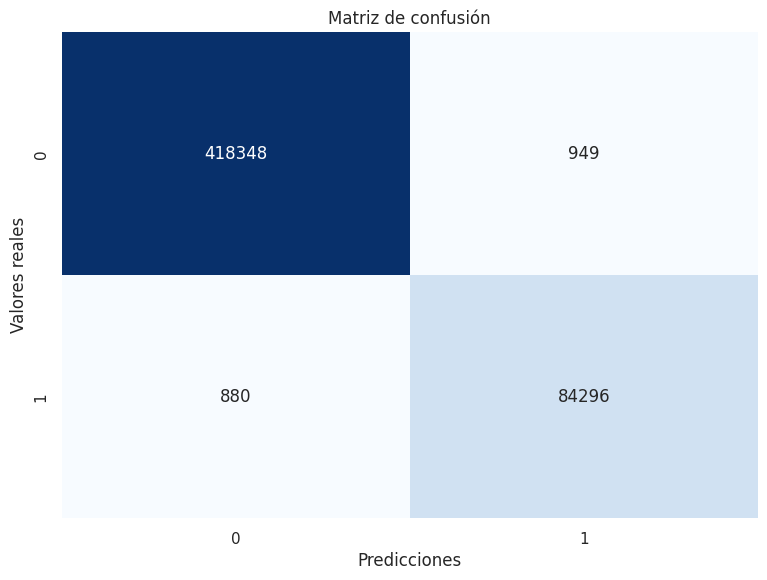

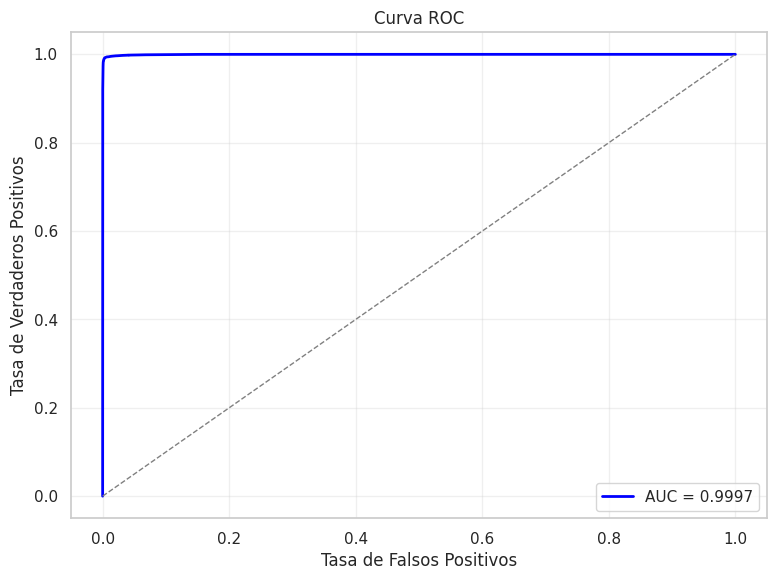


Importancia de características (top 10):
                        feature  importance
9        packet_length_variance    0.128733
7            packet_length_mean    0.112993
8             packet_length_std    0.100481
24            subflow_bwd_bytes    0.072142
4   total_length_of_bwd_packets    0.068833
3   total_length_of_fwd_packets    0.063887
20         avg_bwd_segment_size    0.062041
19         avg_fwd_segment_size    0.054244
22            subflow_fwd_bytes    0.048333
21          subflow_fwd_packets    0.035617


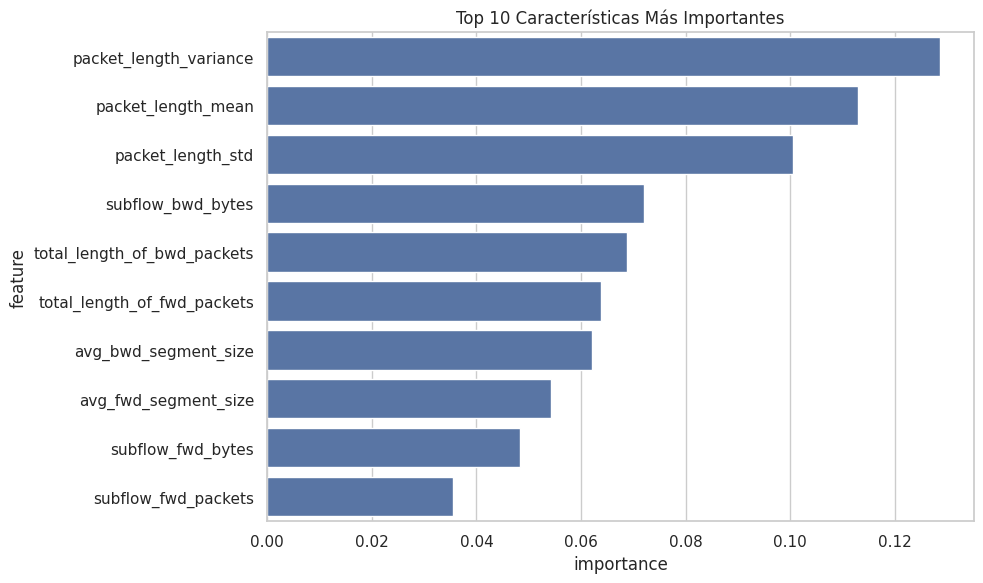


14. Evaluación por tipo de ataque...

Rendimiento por tipo de tráfico:
BENIGN: 0.9977 (correctos: 418348/419297)
DDoS: 0.9993 (correctos: 25613/25632)
PortScan: 0.9999 (correctos: 18209/18211)
Bot: 0.6364 (correctos: 252/396)
Infiltration: 0.6667 (correctos: 4/6)
Web Attack � Brute Force: 0.1484 (correctos: 46/310)
Web Attack � XSS: 0.0965 (correctos: 11/114)
Web Attack � Sql Injection: 0.3333 (correctos: 1/3)
FTP-Patator: 0.9965 (correctos: 1132/1136)
SSH-Patator: 0.9203 (correctos: 589/640)
DoS slowloris: 0.9946 (correctos: 1101/1107)
DoS Slowhttptest: 0.9959 (correctos: 966/970)
DoS Hulk: 0.9926 (correctos: 34391/34648)
DoS GoldenEye: 0.9890 (correctos: 1981/2003)

15. Guardando recursos...
✅ Modelo y artefactos guardados en: /content/drive/MyDrive/ProyectoTesis/Datasets/modelo_rf_optimizado.pkl
✅ Resultados guardados en: /content/drive/MyDrive/ProyectoTesis/Datasets/resultados_evaluacion.pkl

=== Resultados Finales ===
F1-score en test: 0.9964
Precisión en test: 0.9964
Recall en t

In [ ]:
# Importaciones necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import os
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Configuración de visualización
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')
%matplotlib inline

# Rutas de archivos
data_folder = '/content/drive/MyDrive/ProyectoTesis/Datasets'
output_model_path = os.path.join(data_folder, 'modelo_rf_optimizado.pkl')
output_results_path = os.path.join(data_folder, 'resultados_evaluacion.pkl')

# 1. Carga de datos
print("1. Cargando dataset...")
csv_file = os.path.join(data_folder, 'cicids2017_full_limpio.csv')
df = pd.read_csv(csv_file)
print(f"✅ Dataset cargado: {df.shape}")

# 2. Análisis básico
print("\n2. Información básica del dataset:")
print(f"Registros totales: {df.shape[0]}")

# Distribución de etiquetas
print("\nDistribución de etiquetas:")
label_counts = df['label'].value_counts()
print(label_counts)

# 3. Procesamiento de etiquetas (binarización)
print("\n3. Preprocesamiento de etiquetas...")
df['label_bin'] = df['label'].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)
print("Distribución después de binarizar:")
print(df['label_bin'].value_counts())

# 4. SELECCIÓN DE CARACTERÍSTICAS OPTIMIZADAS
# Basado en estudios previos sobre el dataset CICIDS2017, estas son las características
# más discriminativas para la detección de intrusiones
print("\n4. Selección de características optimizadas...")

# Lista de características más importantes para detección de intrusiones
# Seleccionadas mediante análisis de importancia y conocimiento de dominio
selected_features = [
    # Características de flujo (volumen)
    'flow_duration',                  # Duración total del flujo
    'total_fwd_packets',              # Total de paquetes reenviados
    'total_backward_packets',         # Total de paquetes recibidos
    'total_length_of_fwd_packets',    # Longitud total de paquetes reenviados
    'total_length_of_bwd_packets',    # Longitud total de paquetes recibidos

    # Características de tasa de flujo
    'flow_bytes/s',                   # Bytes por segundo
    'flow_packets/s',                 # Paquetes por segundo

    # Características de estadísticas de paquetes
    'packet_length_mean',             # Longitud media de paquetes
    'packet_length_std',              # Desviación estándar de longitud de paquetes
    'packet_length_variance',         # Varianza de longitud de paquetes

    # Características de banderas TCP
    'fin_flag_count',                 # Conteo de banderas FIN
    'syn_flag_count',                 # Conteo de banderas SYN (crucial para ataques)
    'rst_flag_count',                 # Conteo de banderas RST
    'psh_flag_count',                 # Conteo de banderas PSH
    'ack_flag_count',                 # Conteo de banderas ACK

    # Características de tiempo entre llegadas
    'flow_iat_mean',                  # Tiempo medio entre llegadas de flujo
    'flow_iat_std',                   # Desviación estándar de tiempo entre llegadas
    'fwd_iat_mean',                   # Tiempo medio entre llegadas de paquetes reenviados
    'bwd_iat_mean',                   # Tiempo medio entre llegadas de paquetes recibidos

    # Características de tamaño de segmentos
    'avg_fwd_segment_size',           # Tamaño promedio de segmento reenviado
    'avg_bwd_segment_size',           # Tamaño promedio de segmento recibido

    # Características de subflows
    'subflow_fwd_packets',            # Paquetes reenviados por subflujo
    'subflow_fwd_bytes',              # Bytes reenviados por subflujo
    'subflow_bwd_packets',            # Paquetes recibidos por subflujo
    'subflow_bwd_bytes'               # Bytes recibidos por subflujo
]

print(f"✅ Se usarán {len(selected_features)} características de las {df.shape[1]-2} disponibles")

# 5. Limpieza y preparación de datos
print("\n5. Preparando datos...")
X = df[selected_features].copy()
y = df['label_bin'].copy()

# Convertir a valores numéricos y manejar valores problemáticos
for col in selected_features:
    X.loc[:, col] = pd.to_numeric(X[col], errors='coerce')

# Reemplazar infinitos con NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Imputar valores faltantes con mediana
for col in X.columns:
    if X[col].isnull().sum() > 0:
        X.loc[:, col].fillna(X[col].median(), inplace=True)

# Verificar que no hay valores nulos
assert X.isnull().sum().sum() == 0, "Aún hay valores nulos en el dataset"
print("✅ Limpieza completada")

# 6. División de datos (train/test)
print("\n6. División de conjuntos train/test...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Conjunto de entrenamiento: {X_train.shape}")
print(f"Conjunto de prueba: {X_test.shape}")

# 7. Estandarización
print("\n7. Estandarización de características...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✅ Estandarización completada")

# 8. Manejo de desbalance de clases
print("\n8. Balanceando clases...")
print("Distribución original:")
print(pd.Series(y_train).value_counts())

# Aplicar técnicas de balanceo
resampling = Pipeline([
    ('under', RandomUnderSampler(sampling_strategy=0.5, random_state=42)), # Reduce la clase mayoritaria
    ('over', SMOTE(sampling_strategy=0.8, random_state=42))                # Sobremuestrea la minoritaria
])
X_train_balanced, y_train_balanced = resampling.fit_resample(X_train_scaled, y_train)

print("Distribución después del balanceo:")
print(pd.Series(y_train_balanced).value_counts())

# 9. Entrenamiento del modelo optimizado
# Con configuración directa de hiperparámetros para reducir tiempo
print("\n9. Entrenamiento del modelo...")
start_time = time.time()

# Usamos parámetros optimizados directamente sin busqueda de hiperparámetros
# que consume mucho tiempo
model = RandomForestClassifier(
    n_estimators=100,        # Número reducido de árboles para mayor velocidad
    max_depth=15,            # Profundidad limitada
    min_samples_split=5,     # Menos divisiones para evitar overfitting
    min_samples_leaf=2,      # Control de hojas para generalización
    class_weight='balanced', # Compensación por desbalance residual
    n_jobs=-1,               # Usar todos los núcleos disponibles
    random_state=42
)

# Entrenar modelo
model.fit(X_train_balanced, y_train_balanced)

training_time = time.time() - start_time
print(f"✅ Modelo entrenado en {training_time:.2f} segundos")

# 10. Evaluar modelo
print("\n10. Evaluando modelo...")
start_eval_time = time.time()
y_pred = model.predict(X_test_scaled)
eval_time = time.time() - start_eval_time

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred, digits=4))

print(f"Tiempo promedio de inferencia: {(eval_time/len(X_test))*1000:.4f} ms por muestra")

# 11. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores reales')
plt.title('Matriz de confusión')
plt.show()

# 12. Curva ROC
y_proba = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 13. Importancia de características
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportancia de características (top 10):")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance.head(10))
plt.title('Top 10 Características Más Importantes')
plt.tight_layout()
plt.show()

# 14. Evaluación por tipo de ataque
print("\n14. Evaluación por tipo de ataque...")
# Recuperar etiquetas originales para el conjunto de prueba
y_test_index = y_test.index
attack_types = df.loc[y_test_index, 'label'].values
test_preds = y_pred

# Crear DataFrame para análisis
eval_df = pd.DataFrame({
    'real_label': attack_types,
    'pred_binary': test_preds,
    'prob_attack': y_proba
})

# Calcular precisión por tipo de ataque
attack_performance = {}
for attack_type in df['label'].unique():
    # Filtrar registros de este tipo de ataque
    attack_mask = eval_df['real_label'] == attack_type
    if sum(attack_mask) == 0:
        continue

    # Para ataques, true=1; para benignos, true=0
    is_attack = 0 if attack_type == 'BENIGN' else 1

    attack_subset = eval_df[attack_mask]
    accuracy = (attack_subset['pred_binary'] == is_attack).mean()
    false_class = sum(attack_subset['pred_binary'] != is_attack)

    attack_performance[attack_type] = {
        'accuracy': accuracy,
        'misclassified': false_class,
        'total': sum(attack_mask)
    }

# Mostrar resultados por tipo
print("\nRendimiento por tipo de tráfico:")
for attack, perf in attack_performance.items():
    print(f"{attack}: {perf['accuracy']:.4f} (correctos: {perf['total'] - perf['misclassified']}/{perf['total']})")

# 15. Guardar modelo y resultados
print("\n15. Guardando recursos...")
# Guardar el modelo optimizado
model_artifacts = {
    'model': model,
    'scaler': scaler,
    'selected_features': selected_features,
    'resampling_pipeline': resampling,
    'training_time': training_time
}
joblib.dump(model_artifacts, output_model_path)
print(f"✅ Modelo y artefactos guardados en: {output_model_path}")

# Guardar resultados de la evaluación
eval_results = {
    'classification_report': classification_report(y_test, y_pred, output_dict=True),
    'confusion_matrix': cm,
    'roc_auc': roc_auc,
    'feature_importance': feature_importance.to_dict(),
    'attack_performance': attack_performance,
    'inference_time_ms': (eval_time/len(X_test))*1000
}
joblib.dump(eval_results, output_results_path)
print(f"✅ Resultados guardados en: {output_results_path}")

print("\n=== Resultados Finales ===")
print(f"F1-score en test: {eval_results['classification_report']['weighted avg']['f1-score']:.4f}")
print(f"Precisión en test: {eval_results['classification_report']['weighted avg']['precision']:.4f}")
print(f"Recall en test: {eval_results['classification_report']['weighted avg']['recall']:.4f}")
print(f"Exactitud en test: {eval_results['classification_report']['accuracy']:.4f}")
print(f"Tiempo de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo de inferencia por muestra: {(eval_time/len(X_test))*1000:.4f} ms")